<h1>Imports</h1>

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

C:\Users\MSH\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h1>Load Data</h1>

In [2]:
file_path = "../Data/Preprocessed/"

data = pd.read_parquet(file_path + "featured_training_data_V2.parquet", engine="fastparquet")
print("Shape:", data.shape)
print("Sales range:", round(data['Sales'].min(), 2), "->", round(data['Sales'].max(), 2))

Shape: (844338, 20)
Sales range: 3.83 -> 10.63


<h1>Train/Test Split <span style="font-size: 22px;">By date not random</span></h1>


We split the data **by date order** (85% train / 15% test), NOT randomly.

### Why not random split?
This is a **Time Series** problem — the model must learn from the past to predict the future.
A random split would cause **data leakage**, where the model sees future data during training, giving falsely high scores.

- **Train set:** first 717,687 records (older dates)
- **Test set:**  last 126,651 records (most recent dates)

In [3]:
FEATURES = [
    'Store_TargetEnc', 'DayOfWeek', 'CompetitionDistance', 'CompetitionDistanceMissing',
    'CompetitionOpenMissing', 'StateHoliday', 'SchoolHoliday',
    'Promo', 'Promo2', 'StoreType', 'Assortment',
    'Year', 'Week', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd',
    'CompetitionOpenMonths', 'Promo2ActiveWeeks', 'IsPromo2Active'
]
TARGET = 'Sales'

X = data[FEATURES]
y = data[TARGET]

SPLIT_RATIO = 0.85
split_idx = int(len(data) * SPLIT_RATIO)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (717687, 19) | Test: (126651, 19)


<h1>Evaluation Function</h1>

We evaluate the model on **two scales**:

| Scale | Metric | Description |
|-------|--------|-------------|
| Log Scale | MAE, RMSE, R² | Matches the scale the model was trained on |
| Original Scale (€) | MAE, RMSE, MAPE | Human-readable — actual sales error in Euros |

Since `Sales` was log-transformed during cleaning, we apply `np.expm1()` (reverse of log) to convert predictions back to real Euro values before computing original scale metrics.

- **MAE** — average error per prediction
- **RMSE** — penalizes large errors more heavily — higher sensitivity to outliers
- **R²** — how much of the sales variance the model explains (closer to 1 = better)
- **MAPE** — error as a percentage of actual sales — useful for comparing stores of different sizes

In [4]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)

    mae_orig  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse_orig = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mape      = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  [Log Scale]")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"\n  [Original Scale (Sales in €)]")
    print(f"  MAE:  {mae_orig:.2f}")
    print(f"  RMSE: {rmse_orig:.2f}")
    print(f"  MAPE: {mape:.2f}%")

    return {
        "mae":       mae,
        "rmse":      rmse,
        "r2":        r2,
        "mae_orig":  mae_orig,
        "rmse_orig": rmse_orig,
        "mape":      mape
    }

<h1>MLflow Setup</h1>

**MLflow** is our experiment tracking tool — part of the MLOps pipeline.

It automatically records for each run:
- **Parameters** → model hyperparameters (learning rate, n_estimators, etc.)
- **Metrics** → MAE, RMSE, R² for each experiment
- **Model artifact** → the trained pipeline saved for later use

All runs are grouped under one experiment: `rossmann-sales-forecasting`

We use `os.path.abspath()` to convert the relative path `../mlruns` into a full absolute path,
then format it as `file:///F:/...` — this is required on Windows so MLflow UI can correctly
locate and display all runs and artifacts.

To view the MLflow dashboard, run in terminal:

mlflow ui --backend-store-uri "file:///F:/DEPI_R4_AI&Data_Science/Graduation_Project/code/sales-forecasting-optimization/mlruns"

Then open: http://127.0.0.1:5000

In [5]:
import os
import mlflow
from pathlib import Path

notebook_dir = Path(os.getcwd())
mlruns_path  = (notebook_dir / "../mlruns").resolve()

mlflow.set_tracking_uri("file:///" + str(mlruns_path).replace("\\", "/"))
mlflow.set_experiment("rossmann-sales-forecasting")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("mlruns path:", mlruns_path)

MLflow tracking URI: file:///F:/DEPI_R4_AI&Data_Science/Graduation_Project/code/sales-forecasting-optimization/mlruns
mlruns path: F:\DEPI_R4_AI&Data_Science\Graduation_Project\code\sales-forecasting-optimization\mlruns


<h1>LightGBM + MLflow</h1>

We use **LightGBM (Light Gradient Boosting Machine)** — a fast, efficient tree-based model well-suited for tabular data.

### Pipeline Structure:
Input Features → StandardScaler → LightGBM Regressor → Predicted Sales (log)

<h1>HYPERPARAMETER TUNING — LightGBM</h1>

In [ ]:
lgbm_param_dist = {
    "model__n_estimators":      [500, 1000, 1500],
    "model__learning_rate":     [0.01, 0.03, 0.05],
    "model__num_leaves":        [31, 63, 127],
    "model__max_depth":         [-1, 6, 8],
    "model__subsample":         [0.7, 0.8, 0.9],
    "model__min_child_samples": [10, 20, 30],
}

lgbm_search_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

lgbm_search = RandomizedSearchCV(
    lgbm_search_pipeline,
    lgbm_param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)

print("Best LightGBM Params:")
print(lgbm_search.best_params_)
print(f"Best CV R²: {lgbm_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best LightGBM Params:
{'model__subsample': 0.9, 'model__num_leaves': 63, 'model__n_estimators': 1500, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.03}
Best CV R²: 0.8627


`StandardScaler` is included in the pipeline to standardize features, ensuring consistent preprocessing for any new input data at prediction time.

### Hyperparameters:
| Parameter | Value | Purpose |
|-----------|-------|---------|
| n_estimators | 1500 | number of trees |
| learning_rate | 0.03 | step size per tree — smaller = more precise |
| num_leaves | 63 | controls model complexity |
| max_depth | -1 | no depth limit |
| subsample | 0.9 | 90% of data per tree |
| min_child_samples | 10 | minimum samples per leaf |

### MLflow Logging:
After training, we log parameters, metrics, and the full pipeline to MLflow for tracking and future deployment.

In [8]:
lgbm_params = {
    "n_estimators":     1500,
    "learning_rate":    0.03,
    "num_leaves":       63,
    "max_depth":        -1,
    "subsample":        0.9,
    "min_child_samples": 10,
    "random_state":     42,
    "n_jobs":           -1,
    "verbose":          1,
}

with mlflow.start_run(run_name="LightGBM_tuned"):

    lgbm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LGBMRegressor(**lgbm_params))
    ])

    lgbm_pipeline.fit(X_train, y_train)
    y_pred = lgbm_pipeline.predict(X_test)

    metrics = evaluate(y_test, y_pred, "LightGBM")

    mlflow.log_params(lgbm_params)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(lgbm_pipeline, "lgbm_model")

    print("\nLogged to MLflow")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1109
[LightGBM] [Info] Number of data points in the train set: 717687, number of used features: 19
[LightGBM] [Info] Start training from score 8.765292


2026/07/08 07:57:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 07:57:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  LightGBM
  [Log Scale]
  MAE:  0.1320
  RMSE: 0.1835
  R²:   0.8225

  [Original Scale (Sales in €)]
  MAE:  839.31
  RMSE: 1200.21
  MAPE: 13.72%

Logged to MLflow


<h1>XGBoost + MLflow</h1>

We use **XGBoost (Extreme Gradient Boosting)** — another powerful tree-based model,
trained using the same pipeline structure as LightGBM for fair comparison.

### Pipeline Structure:

Input Features → StandardScaler → XGBoost Regressor → Predicted Sales (log)

<h1>HYPERPARAMETER TUNING — XGBoost</h1>

In [ ]:
xgb_param_dist = {
    "model__n_estimators":    [500, 1000, 1500],
    "model__learning_rate":   [0.01, 0.03, 0.05],
    "model__max_depth":       [4, 6, 8],
    "model__subsample":       [0.7, 0.8, 0.9],
    "model__colsample_bytree":[0.7, 0.8, 0.9],
    "model__min_child_weight":[10, 20, 30],
}

xgb_search_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"))
])

xgb_search = RandomizedSearchCV(
    xgb_search_pipeline,
    xgb_param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Params:")
print(xgb_search.best_params_)
print(f"Best CV R²: {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Params:
{'model__subsample': 0.8, 'model__n_estimators': 1000, 'model__min_child_weight': 20, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}
Best CV R²: 0.8644


### Hyperparameters:
| Parameter | Value | Purpose |
|-----------|-------|---------|
| n_estimators | 1000 | number of trees |
| learning_rate | 0.03 | step size per tree |
| max_depth | 8 | maximum tree depth |
| subsample | 0.7 | 70% of data per tree — reduces overfitting |
| colsample_bytree | 0.8 | 80% of features per tree |
| min_child_weight | 20 | minimum samples per leaf |
| tree_method | hist | faster histogram-based training algorithm |

### MLflow Logging:
Parameters, metrics, and the full pipeline are logged to MLflow under the same experiment
`rossmann-sales-forecasting` for direct comparison with LightGBM runs.

In [9]:
xgb_params = {
    "n_estimators":     1000,
    "learning_rate":    0.03,
    "max_depth":        8,
    "subsample":        0.7,
    "colsample_bytree": 0.8,
    "min_child_weight": 20,
    "random_state":     42,
    "n_jobs":           -1,
    "verbose":          1,
    "tree_method":      "hist"
}

with mlflow.start_run(run_name="XGBoost_tuned"):

    xgb_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  XGBRegressor(**xgb_params))
    ])

    xgb_pipeline.fit(X_train, y_train)
    y_pred = xgb_pipeline.predict(X_test)

    metrics = evaluate(y_test, y_pred, "XGBoost")

    mlflow.log_params(xgb_params)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(xgb_pipeline, "xgb_model")

    print("\nLogged to MLflow")

2026/07/08 07:58:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost
  [Log Scale]
  MAE:  0.1285
  RMSE: 0.1792
  R²:   0.8306

  [Original Scale (Sales in €)]
  MAE:  815.18
  RMSE: 1150.54
  MAPE: 13.70%


2026/07/08 07:58:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Logged to MLflow


<h1>Comparison</h1>

After training and tuning both models, we compare their best results side by side.

| Model | R² | MAE (€) | RMSE (€) | MAPE |
|-------|----|---------|----------|------|
| LightGBM_tuned | 0.8225 | 839.31 € | 1,200.21 € | 13.72% |
| XGBoost_tuned | 0.8306 | 815.18 € | 1,150.54 € | 13.70% |

**Winner: XGBoost** — higher R² and lower MAE across all metrics.

The model with the highest **R²** is selected as the best model to register for deployment.

In [11]:
results = pd.DataFrame({
    "Model": ["LightGBM_tuned", "XGBoost_tuned"],
    "R²":    [0.8225,  0.8306],
    "MAE €": [839.31,  815.18],
    "RMSE €":[1200.21, 1150.54],
    "MAPE %": [13.72, 13.70]
})
print(results.to_string(index=False))

best = results.loc[results["R²"].idxmax(), "Model"]
print(f"\nBest Model: {best}")

         Model     R²  MAE €  RMSE €  MAPE %
LightGBM_tuned 0.8225 839.31 1200.21   13.72
 XGBoost_tuned 0.8306 815.18 1150.54   13.70

Best Model: XGBoost_tuned


<h1>Residuals Analysis</h1>

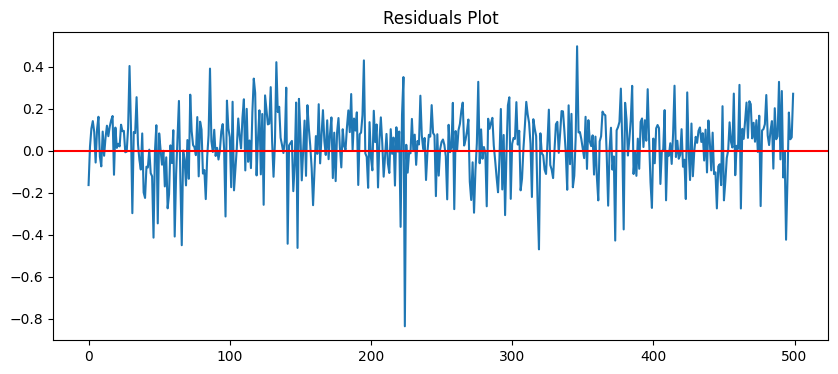

In [12]:
from matplotlib import pyplot as plt

residuals = y_test - y_pred
plt.figure(figsize=(10,4))
plt.plot(residuals.values[:500])
plt.axhline(0, color='red')
plt.title("Residuals Plot")
plt.show()

<h1>Registered Model</h1>

## Register Best Model

We register the best performing model — **XGBoost** — in MLflow's Model Registry.

### Why register a model?
- Gives the model a **versioned, named entry** in MLflow
- Makes it easy to **load and deploy** later without re-training
- Tracks which version is in **Staging** or **Production**

The registered model will appear under `mlruns/models/rossmann-sales-forecasting-model`
and can be loaded anywhere using:
```python
mlflow.sklearn.load_model("models:/rossmann-sales-forecasting-model/1")
```

In [13]:
best_pipeline = xgb_pipeline

with mlflow.start_run(run_name="Best_Model_XGBoost"):
    mlflow.sklearn.log_model(
        best_pipeline,
        "best_model",
        registered_model_name="rossmann-sales-forecasting-model"
    )
    mlflow.log_metrics({
        "r2":        0.8306,
        "mae":       0.1285,
        "rmse":      0.1792,
        "mae_orig":  815.18,
        "rmse_orig": 1150.54,
        "mape":      0.1370
    })
    print("Best Model Registered")

2026/07/08 08:14:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 08:14:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Model Registered


Registered model 'rossmann-sales-forecasting-model' already exists. Creating a new version of this model...
Created version '14' of model 'rossmann-sales-forecasting-model'.


<h1>MLflow UI</h1>

Open the MLflow dashboard to visually compare all runs.

### What you can do:
- Compare all runs (LightGBM vs XGBoost) side by side
- Filter and sort by any metric (R², MAE, RMSE)
- View hyperparameters for each run
- Access and download the registered model artifact

### Important
The terminal running the MLflow UI must stay open while browsing the dashboard.
If port 5000 is busy, use `--port 5001` instead.

In [14]:
print("Run in terminal:")
print('mlflow ui --backend-store-uri "file:///F:/DEPI_R4_AI&Data_Science/Graduation_Project/code/sales-forecasting-optimization/mlruns"')
print("Then open: http://127.0.0.1:5000")

Run in terminal:
mlflow ui --backend-store-uri "file:///F:/DEPI_R4_AI&Data_Science/Graduation_Project/code/sales-forecasting-optimization/mlruns"
Then open: http://127.0.0.1:5000


In [15]:
import joblib

joblib.dump(xgb_pipeline, "../src/model.pkl")

['../src/model.pkl']